In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import json
from collections import Counter
from torchvision.ops import masks_to_boxes
import torch
import matplotlib.patches as patches
from skimage.measure import label, regionprops
from datetime import datetime
from inference_sdk import InferenceHTTPClient
from tqdm import tqdm
from PIL import Image
from decouple import config
from inference import get_model
import random
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
!unzip "/content/drive/MyDrive/CompVision/mixed_flowers.zip" -d "/content/"

## Flower classification dataset:

In [ ]:
base = "flower_classification/progetto-finale-flowes"
splits = ["train", "valid", "test"]
classes = ["daisy", "dandelion"]

for split in splits:
    split_total = 0
    print(f"\n--- {split} ---")
    for cls in classes:
        folder = os.path.join(base, split, cls)
        all_files = os.listdir(folder)
        real_files = [f for f in all_files if not f.startswith("._")]
        count = len(real_files)
        split_total += count
        print(f"  {cls}: {count} images")
    print(f"  Total: {split_total} images")

print(f"\n--- Overall ---")
grand_total = 0
for cls in classes:
    cls_total = sum(
        len([f for f in os.listdir(os.path.join(base, s, cls)) if not f.startswith("._")])
        for s in splits
    )
    grand_total += cls_total
    print(f"  {cls}: {cls_total} images total")
print(f"  Grand total: {grand_total} images")


--- train ---
  daisy: 529 images
  dandelion: 746 images
  Total: 1275 images

--- valid ---
  daisy: 163 images
  dandelion: 201 images
  Total: 364 images

--- test ---
  daisy: 77 images
  dandelion: 105 images
  Total: 182 images

--- Overall ---
  daisy: 769 images total
  dandelion: 1052 images total
  Grand total: 1821 images


## Generate detection annotations for the classification dataset

Use a Roboflow workflow (`detect-and-classify`) via the Inference API to detect flowers in each image.
The class label (daisy/dandelion) comes from the folder name, not the detector.
All splits are saved into a single `_annotations.coco.json`.

In [2]:
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="iOeJRFzSr5XslG9YlFs6",
)

In [6]:
# Load model directly (downloads once, runs locally)
model = get_model(model_id="flower-detection-fscsr/2")

cls_base = "flower_classification/progetto-finale-flowes"
splits = ["train", "valid", "test"]
classes = {"daisy": 0, "dandelion": 1}

categories = [
    {"id": 0, "name": "daisy", "supercategory": "flower"},
    {"id": 1, "name": "dandelion", "supercategory": "flower"},
]

coco = {
    "info": {
        "year": "2026", "version": "1.0",
        "description": "Flower classification dataset with detection boxes",
        "contributor": "", "url": "",
        "date_created": datetime.now().isoformat(),
    },
    "licenses": [{"id": 1, "url": "", "name": "Unknown"}],
    "categories": categories,
    "images": [],
    "annotations": [],
}

img_id = 0
ann_id = 0

for split in splits:
    for cls_name, cls_id in classes.items():
        folder = os.path.join(cls_base, split, cls_name)
        files = sorted([f for f in os.listdir(folder)
                        if not f.startswith("._") and f.lower().endswith((".jpg", ".jpeg", ".png"))])

        for fname in tqdm(files, desc=f"{split}/{cls_name}"):
            img_path = os.path.join(folder, fname)
            img = Image.open(img_path)
            w, h = img.size
            rel_path = f"{split}/{cls_name}/{fname}"

            coco["images"].append({
                "id": img_id,
                "file_name": rel_path,
                "height": h,
                "width": w,
            })

            results = model.infer(image=img_path, confidence=0.4)
            for pred in results[0].predictions:
                bx = int(pred.x - pred.width / 2)
                by = int(pred.y - pred.height / 2)
                bw = int(pred.width)
                bh = int(pred.height)

                coco["annotations"].append({
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": cls_id,
                    "bbox": [bx, by, bw, bh],
                    "area": bw * bh,
                    "iscrowd": 0,
                    "segmentation": [],
                })
                ann_id += 1

            img_id += 1

out_path = os.path.join(cls_base, "_annotations.coco.json")
with open(out_path, "w") as f:
    json.dump(coco, f)

print(f"\nSaved to {out_path}")
print(f"Images:      {len(coco['images'])}")
print(f"Annotations: {len(coco['annotations'])} bounding boxes")


test/dandelion: 100%|██████████| 105/105 [00:14<00:00,  7.03it/s]



Saved to flower_classification/progetto-finale-flowes\_annotations.coco.json
Images:      1821
Annotations: 1510 bounding boxes


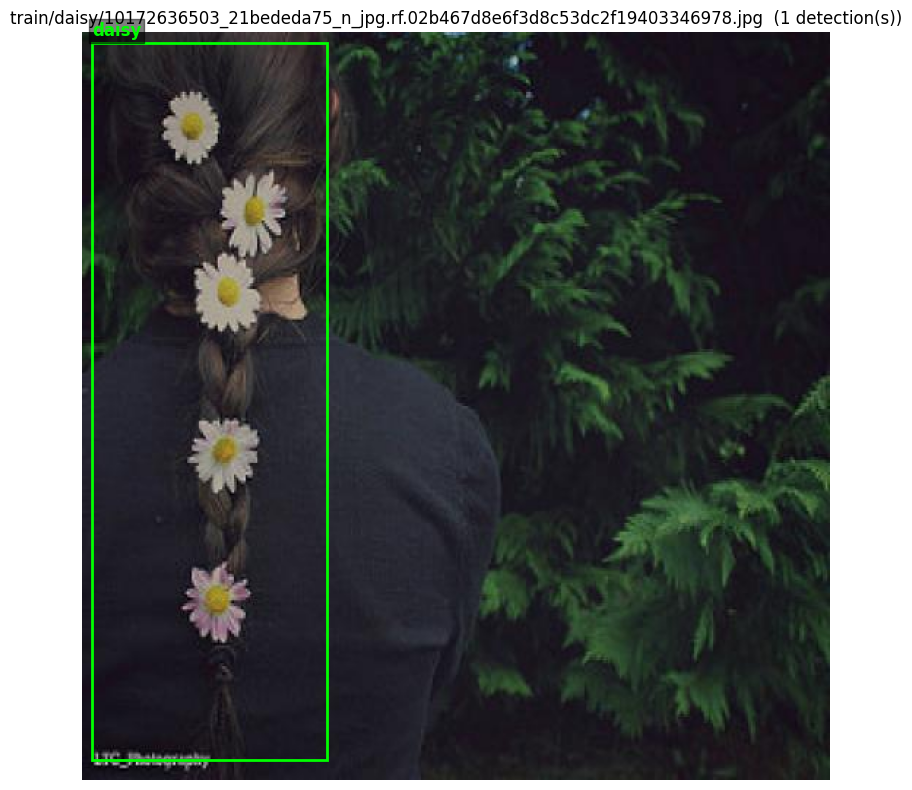

In [10]:
cls_base = "flower_classification/progetto-finale-flowes"

with open(os.path.join(cls_base, "_annotations.coco.json"), "r") as f:
    coco_data = json.load(f)

sample_img = coco_data["images"][3]
sample_anns = [a for a in coco_data["annotations"] if a["image_id"] == sample_img["id"]]

img = Image.open(os.path.join(cls_base, sample_img["file_name"]))

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img)

cat_map = {c["id"]: c["name"] for c in coco_data["categories"]}
colors = {"daisy": "lime", "dandelion": "cyan"}

for ann in sample_anns:
    x, y, w, h = ann["bbox"]
    name = cat_map[ann["category_id"]]
    color = colors.get(name, "red")
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    ax.text(x, y - 5, name, color=color, fontsize=12, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.5, pad=2))

ax.set_title(f"{sample_img['file_name']}  ({len(sample_anns)} detection(s))")
ax.axis("off")
plt.tight_layout()
plt.show()

## Flower segmentation dataset:

Flower images:          8189
Segmentation masks:     8189

Total labels:           8189
Number of classes:      102 (classes 1 to 102)


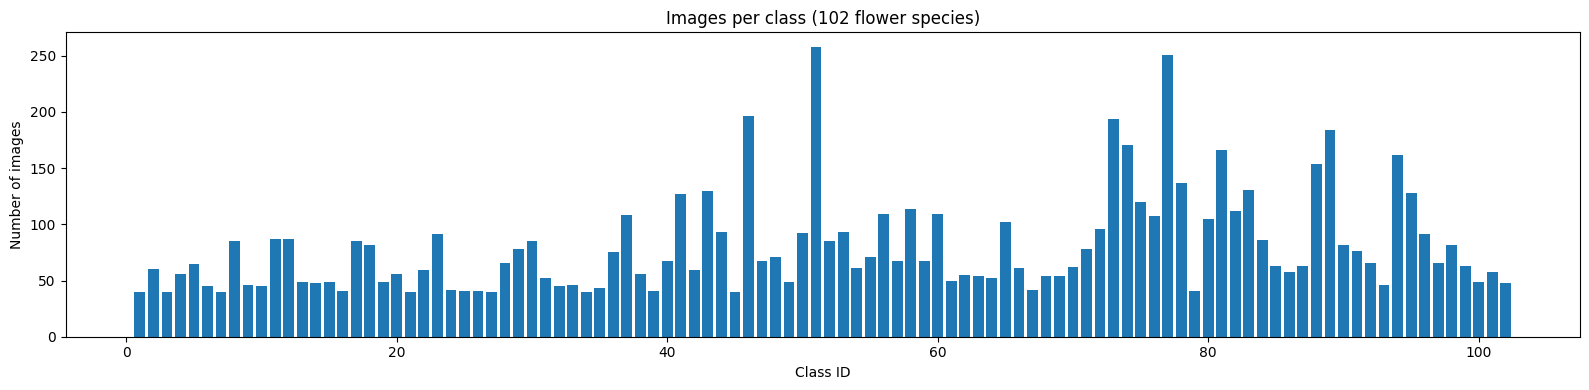


Smallest class:  class 1 with 40 images
Largest class:   class 51 with 258 images
Mean per class:  80.3 images

--- setid.mat (predefined splits) ---
  Train:      1020 images (indices 28-8177)
  Validation: 1020 images (indices 17-8187)
  Test:       6149 images (indices 1-8189)
  Total:      8189 images
  No overlap between splits ✓


In [ ]:
seg_base = "flower_segmentation"

# --- Count images and segmentation masks ---
jpg_files = [f for f in os.listdir(f"{seg_base}/jpg")]
seg_files = [f for f in os.listdir(f"{seg_base}/segmim")]

print(f"Flower images:          {len(jpg_files)}")
print(f"Segmentation masks:     {len(seg_files)}")

# --- Analyze imagelabels.mat ---
labels_mat = scipy.io.loadmat(f"{seg_base}/imagelabels.mat")
labels = labels_mat["labels"].flatten()

print(f"\nTotal labels:           {len(labels)}")
print(f"Number of classes:      {len(np.unique(labels))} (classes {labels.min()} to {labels.max()})")

vals, counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(vals, counts)
ax.set_xlabel("Class ID")
ax.set_ylabel("Number of images")
ax.set_title(f"Images per class ({len(vals)} flower species)")
plt.tight_layout()
plt.show()

print(f"\nSmallest class:  class {vals[counts.argmin()]} with {counts.min()} images")
print(f"Largest class:   class {vals[counts.argmax()]} with {counts.max()} images")
print(f"Mean per class:  {counts.mean():.1f} images")

# --- Analyze setid.mat ---
setid = scipy.io.loadmat(f"{seg_base}/setid.mat")

trnid = setid["trnid"].flatten()
valid = setid["valid"].flatten()
tstid = setid["tstid"].flatten()

print(f"\n--- setid.mat (predefined splits) ---")
print(f"  Train:      {len(trnid)} images (indices {trnid.min()}-{trnid.max()})")
print(f"  Validation: {len(valid)} images (indices {valid.min()}-{valid.max()})")
print(f"  Test:       {len(tstid)} images (indices {tstid.min()}-{tstid.max()})")
print(f"  Total:      {len(trnid) + len(valid) + len(tstid)} images")

# Verify no overlap
assert len(set(trnid) & set(valid)) == 0, "Train/Valid overlap!"
assert len(set(trnid) & set(tstid)) == 0, "Train/Test overlap!"
assert len(set(valid) & set(tstid)) == 0, "Valid/Test overlap!"
print("  No overlap between splits ✓")

In [65]:
labels_mat = scipy.io.loadmat(f"{seg_base}/imagelabels.mat")
all_labels = labels_mat["labels"].flatten()

unique_labels = sorted(set(all_labels))
categories = [{"id": int(cls), "name": f"flower_{cls}", "supercategory": "flower"} for cls in unique_labels]

coco_output = {
    "info": {
        "year": "2026",
        "version": "1.0",
        "description": "Flower segmentation dataset converted to COCO detection format",
        "contributor": "",
        "url": "",
        "date_created": datetime.now().isoformat(),
    },
    "licenses": [{"id": 1, "url": "", "name": "Unknown"}],
    "categories": categories,
    "images": [],
    "annotations": [],
}

jpg_files = [f for f in os.listdir(f"{seg_base}/jpg")]
seg_files = [f for f in os.listdir(f"{seg_base}/segmim")]

ann_id = 0
skipped = 0

for img_id, (image_name, seg_name) in enumerate(zip(jpg_files, seg_files)):
    image = cv2.imread(f"{seg_base}/jpg/{image_name}")
    seg = cv2.imread(f"{seg_base}/segmim/{seg_name}")

    if image is None or seg is None:
        skipped += 1
        continue

    h, w = image.shape[:2]

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    seg_rgb = cv2.cvtColor(seg, cv2.COLOR_BGR2RGB)

    difference = np.abs(image_rgb.astype(np.int16) - seg_rgb.astype(np.int16))
    foreground_mask = ~np.any(difference > 30, axis=-1)
    labeled_mask = label(foreground_mask)
    props = regionprops(labeled_mask)

    # image index is 1-based in the dataset (image_00001.jpg -> label index 0)
    label_idx = img_id
    category_id = int(all_labels[label_idx]) if label_idx < len(all_labels) else 1

    coco_output["images"].append({
        "id": img_id,
        "file_name": image_name,
        "height": h,
        "width": w,
    })

    for prop in props:
        if prop.area < 500:
            continue
        ymin, xmin, ymax, xmax = prop.bbox
        bbox_w = xmax - xmin
        bbox_h = ymax - ymin

        coco_output["annotations"].append({
            "id": ann_id,
            "image_id": img_id,
            "category_id": category_id,
            "bbox": [int(xmin), int(ymin), int(bbox_w), int(bbox_h)],
            "area": int(bbox_w * bbox_h),
            "iscrowd": 0,
            "segmentation": [],
        })
        ann_id += 1

out_path = f"{seg_base}/_annotations.coco.json"
with open(out_path, "w") as f:
    json.dump(coco_output, f)

print(f"Saved to {out_path}")
print(f"Images:      {len(coco_output['images'])}")
print(f"Annotations: {len(coco_output['annotations'])} bounding boxes")
print(f"Categories:  {len(coco_output['categories'])}")
print(f"Skipped:     {skipped} (unreadable files)")

Saved to flower_segmentation/_annotations.coco.json
Images:      8189
Annotations: 14858 bounding boxes
Categories:  102
Skipped:     0 (unreadable files)


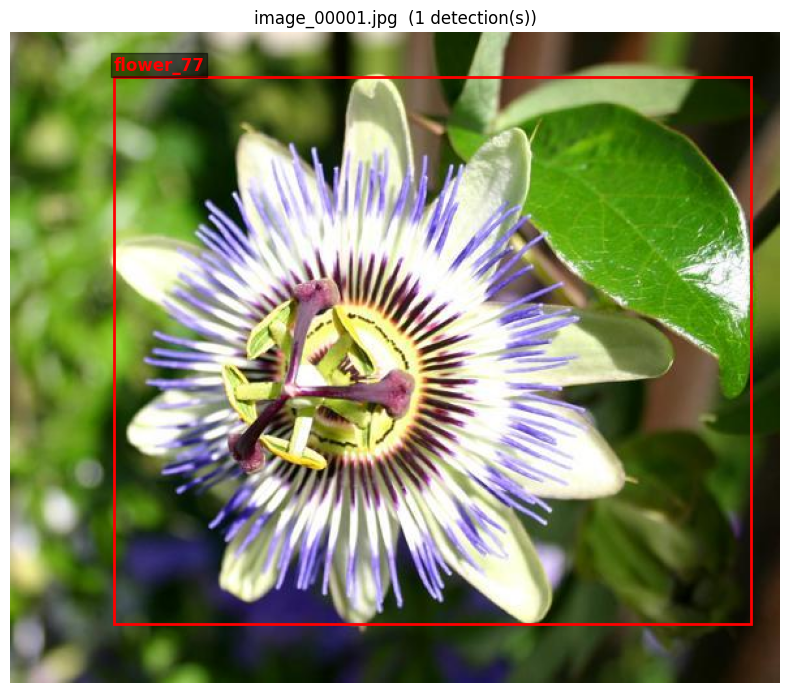

In [11]:
cls_base = "flower_segmentation"

with open(os.path.join(cls_base, "_annotations.coco.json"), "r") as f:
    coco_data = json.load(f)

sample_img = coco_data["images"][0]
sample_anns = [a for a in coco_data["annotations"] if a["image_id"] == sample_img["id"]]

img = Image.open(os.path.join(cls_base, "jpg", sample_img["file_name"]))

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img)

cat_map = {c["id"]: c["name"] for c in coco_data["categories"]}
colors = {"daisy": "lime", "dandelion": "cyan"}

for ann in sample_anns:
    x, y, w, h = ann["bbox"]
    name = cat_map[ann["category_id"]]
    color = colors.get(name, "red")
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    ax.text(x, y - 5, name, color=color, fontsize=12, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.5, pad=2))

ax.set_title(f"{sample_img['file_name']}  ({len(sample_anns)} detection(s))")
ax.axis("off")
plt.tight_layout()
plt.show()

## Flower detection dataset:

- The dataset includes 3336 images.
- Flower are annotated in COCO format.

Images:      3336
Annotations: 4852 bounding boxes
Categories:  14

Class                  ID    Boxes
-----------------------------------
flower                  0        0
0                       1      533
ANGGREK                 2      185
ASTER                   3      197
Aglonema                4      212
Bunga Coleus            5      255
Holiday Cactus          6       12
Kenanga                 7      650
Kupu-Kupu               8      745
Melati                  9      962
ROSE-MAWAR             10       99
Rose-Mawar             11      567
SUN FLOWER             12      224
TULIP                  13      211


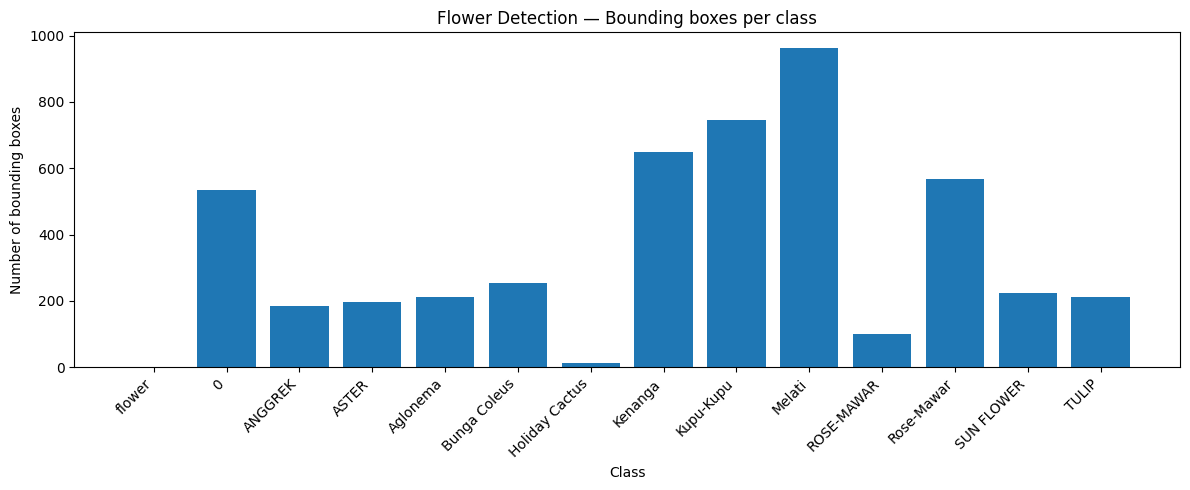


Potential issues:
  - 'flower' (id=0) has 0 annotations — generic/unused category?
  - Duplicate rose classes: ['ROSE-MAWAR', 'Rose-Mawar'] with [99, 567] boxes — consider merging


In [ ]:
det_base = "flower_detection/train"

with open(f"{det_base}/_annotations.coco.json", "r") as f:
    coco = json.load(f)

cat_map = {c["id"]: c["name"] for c in coco["categories"]}
cat_counts = Counter(a["category_id"] for a in coco["annotations"])

print(f"Images:      {len(coco['images'])}")
print(f"Annotations: {len(coco['annotations'])} bounding boxes")
print(f"Categories:  {len(coco['categories'])}")

print(f"\n{'Class':<20} {'ID':>4} {'Boxes':>8}")
print("-" * 35)
for cat in coco["categories"]:
    count = cat_counts.get(cat["id"], 0)
    print(f"{cat['name']:<20} {cat['id']:>4} {count:>8}")

# Bar chart
names = [cat["name"] for cat in coco["categories"]]
counts = [cat_counts.get(cat["id"], 0) for cat in coco["categories"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, counts)
ax.set_xlabel("Class")
ax.set_ylabel("Number of bounding boxes")
ax.set_title("Flower Detection — Bounding boxes per class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Flag potential issues
print("\nPotential issues:")
if cat_counts.get(0, 0) == 0 and "flower" in cat_map.values():
    print("  - 'flower' (id=0) has 0 annotations — generic/unused category?")
rose_ids = [c["id"] for c in coco["categories"] if "rose" in c["name"].lower() or "mawar" in c["name"].lower()]
if len(rose_ids) > 1:
    rose_names = [cat_map[i] for i in rose_ids]
    rose_counts = [cat_counts.get(i, 0) for i in rose_ids]
    print(f"  - Duplicate rose classes: {rose_names} with {rose_counts} boxes — consider merging")

In [12]:
det_base = "flower_detection/train"

with open(f"{det_base}/_annotations.coco.json", "r") as f:
    coco_det = json.load(f)

# 1. Remove unused 'flower' category (id=0, 0 annotations)
coco_det["categories"] = [c for c in coco_det["categories"] if c["id"] != 0]

# 2. Merge 'ROSE-MAWAR' (id=10) into 'Rose-Mawar' (id=11)
for ann in coco_det["annotations"]:
    if ann["category_id"] == 10:
        ann["category_id"] = 11
coco_det["categories"] = [c for c in coco_det["categories"] if c["id"] != 10]

for c in coco_det["categories"]:
    if c["id"] == 11:
        c["name"] = "Rose-Mawar"

with open(f"{det_base}/_annotations.coco.json", "w") as f:
    json.dump(coco_det, f)

# Verify
cat_map = {c["id"]: c["name"] for c in coco_det["categories"]}
cat_counts = Counter(a["category_id"] for a in coco_det["annotations"])

print(f"Images:      {len(coco_det['images'])}")
print(f"Annotations: {len(coco_det['annotations'])} bounding boxes")
print(f"Categories:  {len(coco_det['categories'])}")

print(f"\n{'Class':<20} {'ID':>4} {'Boxes':>8}")
print("-" * 35)
for cat in coco_det["categories"]:
    count = cat_counts.get(cat["id"], 0)
    print(f"{cat['name']:<20} {cat['id']:>4} {count:>8}")

Images:      3336
Annotations: 4852 bounding boxes
Categories:  12

Class                  ID    Boxes
-----------------------------------
0                       1      533
ANGGREK                 2      185
ASTER                   3      197
Aglonema                4      212
Bunga Coleus            5      255
Holiday Cactus          6       12
Kenanga                 7      650
Kupu-Kupu               8      745
Melati                  9      962
Rose-Mawar             11      666
SUN FLOWER             12      224
TULIP                  13      211


## Cross-dataset class analysis — Oxford 102 mapping

In [18]:
oxford_102_names = {
    1: "pink primrose", 2: "hard-leaved pocket orchid", 3: "canterbury bells",
    4: "sweet pea", 5: "english marigold", 6: "tiger lily", 7: "moon orchid",
    8: "bird of paradise", 9: "monkshood", 10: "globe thistle", 11: "snapdragon",
    12: "colt's foot", 13: "king protea", 14: "spear thistle", 15: "yellow iris",
    16: "globe-flower", 17: "purple coneflower", 18: "peruvian lily",
    19: "balloon flower", 20: "giant white arum lily", 21: "fire lily",
    22: "pincushion flower", 23: "fritillary", 24: "red ginger",
    25: "grape hyacinth", 26: "corn poppy", 27: "prince of wales feathers",
    28: "stemless gentian", 29: "artichoke", 30: "sweet william", 31: "carnation",
    32: "garden phlox", 33: "love in the mist", 34: "mexican aster",
    35: "alpine sea holly", 36: "ruby-lipped cattleya", 37: "cape flower",
    38: "great masterwort", 39: "siam tulip", 40: "lenten rose",
    41: "barbeton daisy", 42: "daffodil", 43: "sword lily", 44: "poinsettia",
    45: "bolero deep blue", 46: "wallflower", 47: "marigold", 48: "buttercup",
    49: "oxeye daisy", 50: "common dandelion", 51: "petunia", 52: "wild pansy",
    53: "primula", 54: "sunflower", 55: "pelargonium", 56: "bishop of llandaff",
    57: "gaura", 58: "geranium", 59: "orange dahlia", 60: "pink-yellow dahlia",
    61: "cautleya spicata", 62: "japanese anemone", 63: "black-eyed susan",
    64: "silverbush", 65: "californian poppy", 66: "osteospermum",
    67: "spring crocus", 68: "bearded iris", 69: "windflower", 70: "tree poppy",
    71: "gazania", 72: "azalea", 73: "water lily", 74: "rose", 75: "thorn apple",
    76: "morning glory", 77: "passion flower", 78: "lotus", 79: "toad lily",
    80: "anthurium", 81: "frangipani", 82: "clematis", 83: "hibiscus",
    84: "columbine", 85: "desert-rose", 86: "tree mallow", 87: "magnolia",
    88: "cyclamen", 89: "watercress", 90: "canna lily", 91: "hippeastrum",
    92: "bee balm", 93: "ball moss", 94: "foxglove", 95: "bougainvillea",
    96: "camellia", 97: "mallow", 98: "mexican petunia", 99: "bromelia",
    100: "blanket flower", 101: "trumpet creeper", 102: "blackberry lily",
}

det_english = {
    "0": "unknown", "ANGGREK": "orchid", "ASTER": "aster",
    "Aglonema": "aglaonema", "Bunga Coleus": "coleus",
    "Holiday Cactus": "holiday cactus", "Kenanga": "ylang-ylang",
    "Kupu-Kupu": "butterfly flower", "Melati": "jasmine",
    "Rose-Mawar": "rose", "SUN FLOWER": "sunflower", "TULIP": "tulip",
}

# --- Load all 3 COCO files ---
with open("flower_classification/progetto-finale-flowes/_annotations.coco.json") as f:
    coco_cls = json.load(f)
with open("flower_segmentation/_annotations.coco.json") as f:
    coco_seg = json.load(f)
with open("flower_detection/train/_annotations.coco.json") as f:
    coco_det = json.load(f)

# --- 1. Classification ---
cls_cat = {c["id"]: c["name"] for c in coco_cls["categories"]}
cls_counts = Counter(a["category_id"] for a in coco_cls["annotations"])
print("=" * 60)
print("CLASSIFICATION  (2 classes)")
print(f"{'Class':<25} {'Boxes':>8}")
print("-" * 35)
for cid in sorted(cls_counts):
    print(f"{cls_cat[cid]:<25} {cls_counts[cid]:>8}")
print(f"{'TOTAL':<25} {sum(cls_counts.values()):>8}")

# --- 2. Segmentation (Oxford 102) — sorted by boxes descending ---
seg_cat = {c["id"]: c["name"] for c in coco_seg["categories"]}
seg_box_counts = Counter(a["category_id"] for a in coco_seg["annotations"])
seg_img_counts = Counter()
for a in coco_seg["annotations"]:
    seg_img_counts[(a["category_id"], a["image_id"])] = 1
seg_img_per_cat = Counter()
for (cid, _) in seg_img_counts:
    seg_img_per_cat[cid] += 1

seg_rows = []
for cid in seg_box_counts:
    generic = seg_cat.get(cid, f"flower_{cid}")
    num = int(generic.split("_")[1]) if "_" in generic else cid
    real = oxford_102_names.get(num, "???")
    seg_rows.append((cid, generic, real, seg_img_per_cat[cid], seg_box_counts[cid]))
seg_rows.sort(key=lambda r: r[4], reverse=True)

print("\n" + "=" * 72)
print("SEGMENTATION  (Oxford 102 Flowers)  — sorted by boxes ↓")
print(f"{'#':>4}  {'ID':>4}  {'flower_N':<14} {'Real name':<28} {'Images':>7} {'Boxes':>7}")
print("-" * 72)
for rank, (cid, generic, real, imgs, boxes) in enumerate(seg_rows, 1):
    print(f"{rank:>4}  {cid:>4}  {generic:<14} {real:<28} {imgs:>7} {boxes:>7}")
print(f"{'':>4}  {'':>4}  {'TOTAL':<14} {'':28} {sum(seg_img_per_cat.values()):>7} {sum(seg_box_counts.values()):>7}")

# --- 3. Detection — sorted by boxes descending ---
det_cat = {c["id"]: c["name"] for c in coco_det["categories"]}
det_box_counts = Counter(a["category_id"] for a in coco_det["annotations"])
det_img_counts = Counter()
for a in coco_det["annotations"]:
    det_img_counts[(a["category_id"], a["image_id"])] = 1
det_img_per_cat = Counter()
for (cid, _) in det_img_counts:
    det_img_per_cat[cid] += 1

det_rows = []
for cid in det_box_counts:
    orig = det_cat.get(cid, "???")
    eng = det_english.get(orig, orig)
    det_rows.append((cid, orig, eng, det_img_per_cat[cid], det_box_counts[cid]))
det_rows.sort(key=lambda r: r[4], reverse=True)

print("\n" + "=" * 72)
print("DETECTION  (Indonesian flower names)  — sorted by boxes ↓")
print(f"{'#':>4}  {'ID':>4}  {'Original':<20} {'English':<20} {'Images':>7} {'Boxes':>7}")
print("-" * 72)
for rank, (cid, orig, eng, imgs, boxes) in enumerate(det_rows, 1):
    print(f"{rank:>4}  {cid:>4}  {orig:<20} {eng:<20} {imgs:>7} {boxes:>7}")
print(f"{'':>4}  {'':>4}  {'TOTAL':<20} {'':20} {sum(det_img_per_cat.values()):>7} {sum(det_box_counts.values()):>7}")

# --- 4. Cross-dataset overlap (fully dynamic) ---

# Normalize every class name to a family via substring grouping
name_to_family = {
    "oxeye daisy": "daisy", "barbeton daisy": "daisy",
    "common dandelion": "dandelion",
    "lenten rose": "lenten rose", "desert-rose": "desert-rose",
    "siam tulip": "tulip",
    "mexican aster": "aster",
    "moon orchid": "orchid", "hard-leaved pocket orchid": "orchid",
    "ruby-lipped cattleya": "orchid",
    "orange dahlia": "dahlia", "pink-yellow dahlia": "dahlia",
    "english marigold": "marigold",
    "mexican petunia": "mexican petunia",
    "water lily": "water lily",
}

def get_family(name):
    return name_to_family.get(name, name)

# Classification
cls_family_boxes = Counter()
for a in coco_cls["annotations"]:
    name = cls_cat[a["category_id"]].lower()
    cls_family_boxes[get_family(name)] += 1

# Segmentation
seg_family_boxes = Counter()
for c in coco_seg["categories"]:
    num = int(c["name"].split("_")[1]) if "_" in c["name"] else c["id"]
    c["_real"] = oxford_102_names.get(num, c["name"]).lower()
seg_real_map = {c["id"]: c["_real"] for c in coco_seg["categories"]}
for a in coco_seg["annotations"]:
    seg_family_boxes[get_family(seg_real_map[a["category_id"]])] += 1

# Detection
det_family_boxes = Counter()
det_eng_map = {}
for c in coco_det["categories"]:
    det_eng_map[c["id"]] = det_english.get(c["name"], c["name"]).lower()
for a in coco_det["annotations"]:
    det_family_boxes[get_family(det_eng_map[a["category_id"]])] += 1

# Union of all families
all_families = set(cls_family_boxes) | set(seg_family_boxes) | set(det_family_boxes)

rows = []
for fam in all_families:
    c = cls_family_boxes.get(fam, 0)
    s = seg_family_boxes.get(fam, 0)
    d = det_family_boxes.get(fam, 0)
    rows.append((fam, c, s, d, c + s + d))
rows.sort(key=lambda r: r[4], reverse=True)

SKIP = {"unknown"}
eligible = [r for r in rows if r[0] not in SKIP]
TOP_N = 16
chosen = {r[0] for r in eligible[:TOP_N]}

print("\n" + "=" * 82)
print(f"ALL FLOWER FAMILIES across datasets  — sorted by total boxes ↓  (top {TOP_N} marked ✓)")
print(f"{'':>3} {'#':>3} {'Family':<24} {'Classification':>15} {'Segmentation':>13} {'Detection':>10} {'Total':>7}")
print("-" * 82)
for rank, (fam, c, s, d, total) in enumerate(rows, 1):
    marker = " ✓" if fam in chosen else "  "
    c_str = str(c) if c else "-"
    s_str = str(s) if s else "-"
    d_str = str(d) if d else "-"
    print(f"{marker} {rank:>3} {fam:<24} {c_str:>15} {s_str:>13} {d_str:>10} {total:>7}")

print(f"\nSelected top {TOP_N}: {', '.join(sorted(chosen))}")

CLASSIFICATION  (2 classes)
Class                        Boxes
-----------------------------------
daisy                          712
dandelion                      798
TOTAL                         1510

SEGMENTATION  (Oxford 102 Flowers)  — sorted by boxes ↓
   #    ID  flower_N       Real name                     Images   Boxes
------------------------------------------------------------------------
   1    51  flower_51      petunia                          210     502
   2    77  flower_77      passion flower                   239     484
   3    94  flower_94      foxglove                         156     427
   4    46  flower_46      wallflower                       196     425
   5    81  flower_81      frangipani                       161     341
   6    37  flower_37      cape flower                      106     308
   7    88  flower_88      cyclamen                         154     303
   8    73  flower_73      water lily                       189     291
   9    60  flower

## Build merged dataset

Count how many images and boxes we'd have from each source, then copy all relevant images and build a unified `_annotations.coco.json`.

In [19]:
def seg_cat_to_family(cat):
    num = int(cat["name"].split("_")[1]) if "_" in cat["name"] else cat["id"]
    return get_family(oxford_102_names.get(num, cat["name"]).lower())

def cls_cat_to_family(cat):
    return get_family(cat["name"].lower())

def det_cat_to_family(cat):
    return get_family(det_english.get(cat["name"], cat["name"]).lower())

sources = [
    ("classification", coco_cls, cls_cat_to_family,
     "flower_classification/progetto-finale-flowes"),
    ("segmentation", coco_seg, seg_cat_to_family,
     "flower_segmentation"),
    ("detection", coco_det, det_cat_to_family,
     "flower_detection/train"),
]

total_images = 0
total_boxes = 0
family_stats = Counter()

for src_name, coco, family_fn, img_base in sources:
    cat_family = {}
    for cat in coco["categories"]:
        fam = family_fn(cat)
        if fam in chosen:
            cat_family[cat["id"]] = fam

    kept_anns = [a for a in coco["annotations"] if a["category_id"] in cat_family]
    kept_img_ids = {a["image_id"] for a in kept_anns}
    src_boxes = Counter(cat_family[a["category_id"]] for a in kept_anns)

    print(f"\n{src_name.upper()}: {len(kept_img_ids)} images, {len(kept_anns)} boxes")
    for fam, count in sorted(src_boxes.items(), key=lambda x: -x[1]):
        print(f"  {fam:<24} {count:>6} boxes")

    total_images += len(kept_img_ids)
    total_boxes += len(kept_anns)
    family_stats += src_boxes

print(f"\n{'=' * 50}")
print(f"MERGED TOTAL: {total_images} images, {total_boxes} boxes, {len(chosen)} classes")
print(f"\nPer-class totals (sorted):")
for fam, count in sorted(family_stats.items(), key=lambda x: -x[1]):
    print(f"  {fam:<24} {count:>6} boxes")


CLASSIFICATION: 1410 images, 1510 boxes
  dandelion                   798 boxes
  daisy                       712 boxes

SEGMENTATION: 2068 images, 4078 boxes
  petunia                     502 boxes
  passion flower              484 boxes
  foxglove                    427 boxes
  wallflower                  425 boxes
  dahlia                      353 boxes
  frangipani                  341 boxes
  cape flower                 308 boxes
  cyclamen                    303 boxes
  orchid                      286 boxes
  daisy                       230 boxes
  rose                        214 boxes
  dandelion                   109 boxes
  sunflower                    96 boxes

DETECTION: 1827 images, 3432 boxes
  jasmine                     962 boxes
  butterfly flower            745 boxes
  rose                        666 boxes
  ylang-ylang                 650 boxes
  sunflower                   224 boxes
  orchid                      185 boxes

MERGED TOTAL: 5305 images, 9020 boxes, 16 c

In [20]:
import shutil

out_dir = "merged_dataset"
out_img_dir = os.path.join(out_dir, "images")
os.makedirs(out_img_dir, exist_ok=True)

unified_cats = sorted(chosen)
family_to_new_id = {name: idx for idx, name in enumerate(unified_cats)}

merged_coco = {
    "info": {
        "year": "2026",
        "version": "1.0",
        "description": "Merged flower detection dataset (classification + segmentation + detection)",
        "date_created": datetime.now().isoformat(),
    },
    "licenses": [{"id": 1, "url": "", "name": "Various"}],
    "categories": [
        {"id": idx, "name": name, "supercategory": "flower"}
        for idx, name in enumerate(unified_cats)
    ],
    "images": [],
    "annotations": [],
}

img_id = 0
ann_id = 0
skipped = 0

for src_name, coco, family_fn, img_base in sources:
    cat_family = {}
    for cat in coco["categories"]:
        fam = family_fn(cat)
        if fam in chosen:
            cat_family[cat["id"]] = fam

    img_anns = {}
    for a in coco["annotations"]:
        if a["category_id"] in cat_family:
            img_anns.setdefault(a["image_id"], []).append(a)

    id_to_img = {img["id"]: img for img in coco["images"]}

    for src_img_id in tqdm(sorted(img_anns.keys()), desc=src_name):
        img_info = id_to_img[src_img_id]
        src_file = img_info["file_name"]

        if src_name == "segmentation":
            src_path = os.path.join(img_base, "jpg", src_file)
        else:
            src_path = os.path.join(img_base, src_file)

        new_fname = f"{src_name}_{os.path.basename(src_file)}"
        dst_path = os.path.join(out_img_dir, new_fname)

        if not os.path.exists(src_path):
            skipped += 1
            continue

        shutil.copy2(src_path, dst_path)

        merged_coco["images"].append({
            "id": img_id,
            "file_name": new_fname,
            "height": img_info["height"],
            "width": img_info["width"],
        })

        for a in img_anns[src_img_id]:
            fam = cat_family[a["category_id"]]
            merged_coco["annotations"].append({
                "id": ann_id,
                "image_id": img_id,
                "category_id": family_to_new_id[fam],
                "bbox": a["bbox"],
                "area": a["area"],
                "iscrowd": a.get("iscrowd", 0),
                "segmentation": a.get("segmentation", []),
            })
            ann_id += 1

        img_id += 1

out_path = os.path.join(out_dir, "_annotations.coco.json")
with open(out_path, "w") as f:
    json.dump(merged_coco, f)

print(f"\nSaved to {out_path}")
print(f"Images:      {len(merged_coco['images'])}")
print(f"Annotations: {len(merged_coco['annotations'])} boxes")
print(f"Categories:  {len(merged_coco['categories'])}")
if skipped:
    print(f"Skipped:     {skipped} images (not found on disk)")

detection: 100%|██████████| 1827/1827 [00:03<00:00, 479.72it/s]



Saved to merged_dataset\_annotations.coco.json
Images:      5305
Annotations: 9020 boxes
Categories:  16


## Dataset card

In [22]:
with open("mixed_flowers/_annotations.coco.json") as f:
    merged = json.load(f)

cat_map = {c["id"]: c["name"] for c in merged["categories"]}
ann_counts = Counter(a["category_id"] for a in merged["annotations"])
widths = [img["width"] for img in merged["images"]]
heights = [img["height"] for img in merged["images"]]

n_images = len(merged["images"])
n_anns = len(merged["annotations"])
n_classes = len(merged["categories"])

print("=" * 65)
print("  MERGED FLOWER DETECTION DATASET — DATASET CARD")
print("=" * 65)

print(f"""
Name:         Merged Flower Detection Dataset
Task:         Object Detection
Format:       COCO JSON (_annotations.coco.json)

Description:
  A unified flower detection dataset built by merging three sources:
    1. Flower Classification (Roboflow) — daisy & dandelion images
       with bounding boxes generated via a pre-trained detector.
    2. Oxford 102 Flowers (Segmentation) — bounding boxes derived
       from instance segmentation masks.
    3. Flower Detection (Roboflow) — native bounding box annotations
       with Indonesian class names mapped to English.

  Classes were grouped into {n_classes} flower families by mapping
  species variants to a common name (e.g. "oxeye daisy" and
  "barbeton daisy" → "daisy"). The top {n_classes} families by total
  annotation count were selected.

Images:       {n_images:,}
Annotations:  {n_anns:,} bounding boxes
Classes:      {n_classes}
""")

print(f"{'Class':<24} {'Boxes':>8} {'% of total':>10}")
print("-" * 44)
for cid, count in sorted(ann_counts.items(), key=lambda x: -x[1]):
    pct = 100.0 * count / n_anns
    print(f"{cat_map[cid]:<24} {count:>8} {pct:>9.1f}%")
print("-" * 44)
print(f"{'TOTAL':<24} {n_anns:>8} {'100.0%':>10}")

print(f"""
Image sizes:
  Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}
  Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}

Annotation format:
  COCO JSON with fields: id, image_id, category_id, bbox [x,y,w,h],
  area, iscrowd, segmentation.

Sources:
  - flower_classification/progetto-finale-flowes/_annotations.coco.json
  - flower_segmentation/_annotations.coco.json
  - flower_detection/train/_annotations.coco.json
""")

  MERGED FLOWER DETECTION DATASET — DATASET CARD

Name:         Merged Flower Detection Dataset
Task:         Object Detection
Format:       COCO JSON (_annotations.coco.json)

Description:
  A unified flower detection dataset built by merging three sources:
    1. Flower Classification (Roboflow) — daisy & dandelion images
       with bounding boxes generated via a pre-trained detector.
    2. Oxford 102 Flowers (Segmentation) — bounding boxes derived
       from instance segmentation masks.
    3. Flower Detection (Roboflow) — native bounding box annotations
       with Indonesian class names mapped to English.

  Classes were grouped into 16 flower families by mapping
  species variants to a common name (e.g. "oxeye daisy" and
  "barbeton daisy" → "daisy"). The top 16 families by total
  annotation count were selected.

Images:       5,305
Annotations:  9,020 bounding boxes
Classes:      16

Class                       Boxes % of total


--------------------------------------------
jasmine                       962      10.7%
daisy                         942      10.4%
dandelion                     907      10.1%
rose                          880       9.8%
butterfly flower              745       8.3%
ylang-ylang                   650       7.2%
petunia                       502       5.6%
passion flower                484       5.4%
orchid                        471       5.2%
foxglove                      427       4.7%
wallflower                    425       4.7%
dahlia                        353       3.9%
frangipani                    341       3.8%
sunflower                     320       3.5%
cape flower                   308       3.4%
cyclamen                      303       3.4%
--------------------------------------------
TOTAL                        9020     100.0%

Image sizes:
  Width  — min: 88, max: 4032, mean: 501
  Height — min: 80, max: 4032, mean: 447

Annotation format:
  COCO JSON with fields: id, 

## Dataset visualization

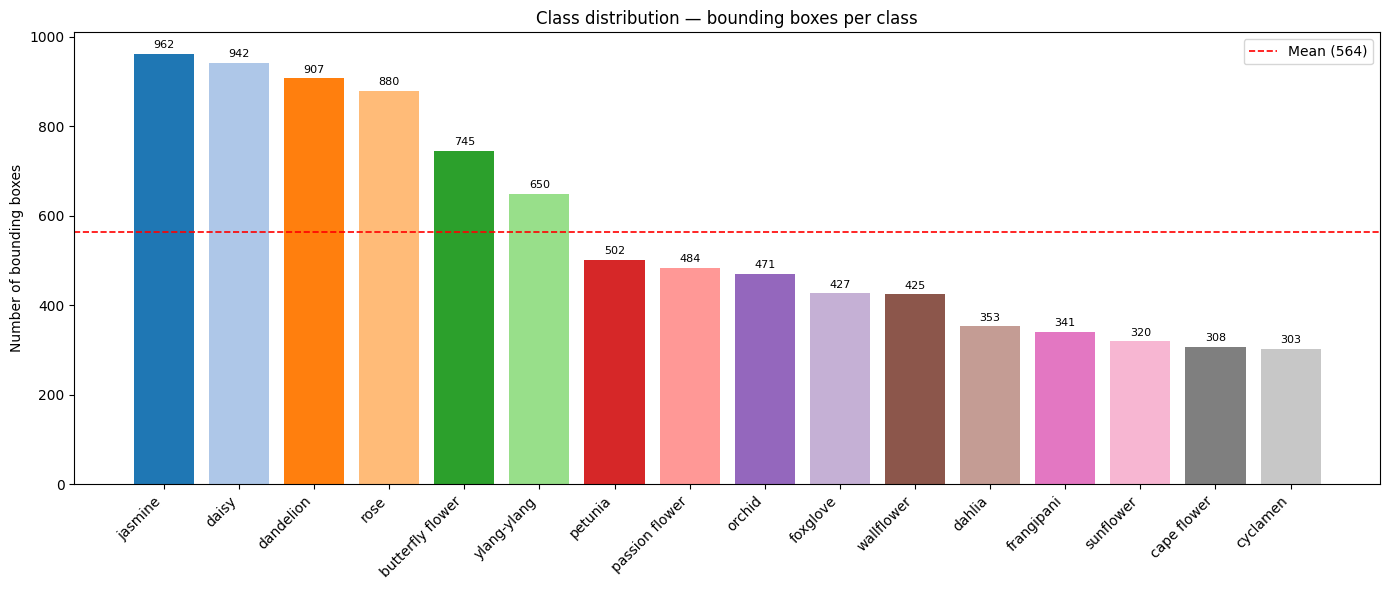

Imbalance ratio (max/min): 3.2x


In [23]:
names_sorted = [cat_map[cid] for cid, _ in sorted(ann_counts.items(), key=lambda x: -x[1])]
counts_sorted = [count for _, count in sorted(ann_counts.items(), key=lambda x: -x[1])]
mean_count = n_anns / n_classes

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(names_sorted)), counts_sorted, color=plt.cm.tab20.colors[:n_classes])
ax.axhline(mean_count, color="red", linestyle="--", linewidth=1.2, label=f"Mean ({mean_count:.0f})")
ax.set_xticks(range(len(names_sorted)))
ax.set_xticklabels(names_sorted, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Number of bounding boxes")
ax.set_title("Class distribution — bounding boxes per class")
ax.legend()

for bar, count in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(count), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

imbalance = max(counts_sorted) / min(counts_sorted)
print(f"Imbalance ratio (max/min): {imbalance:.1f}x")

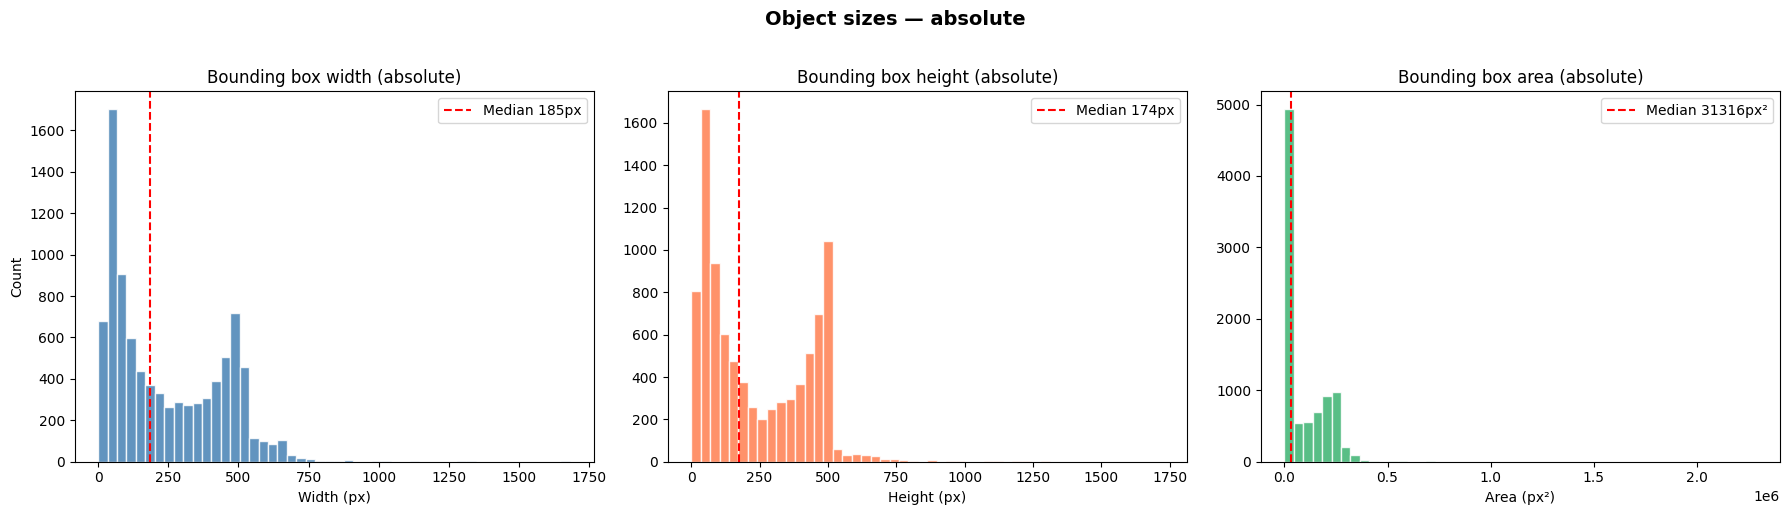

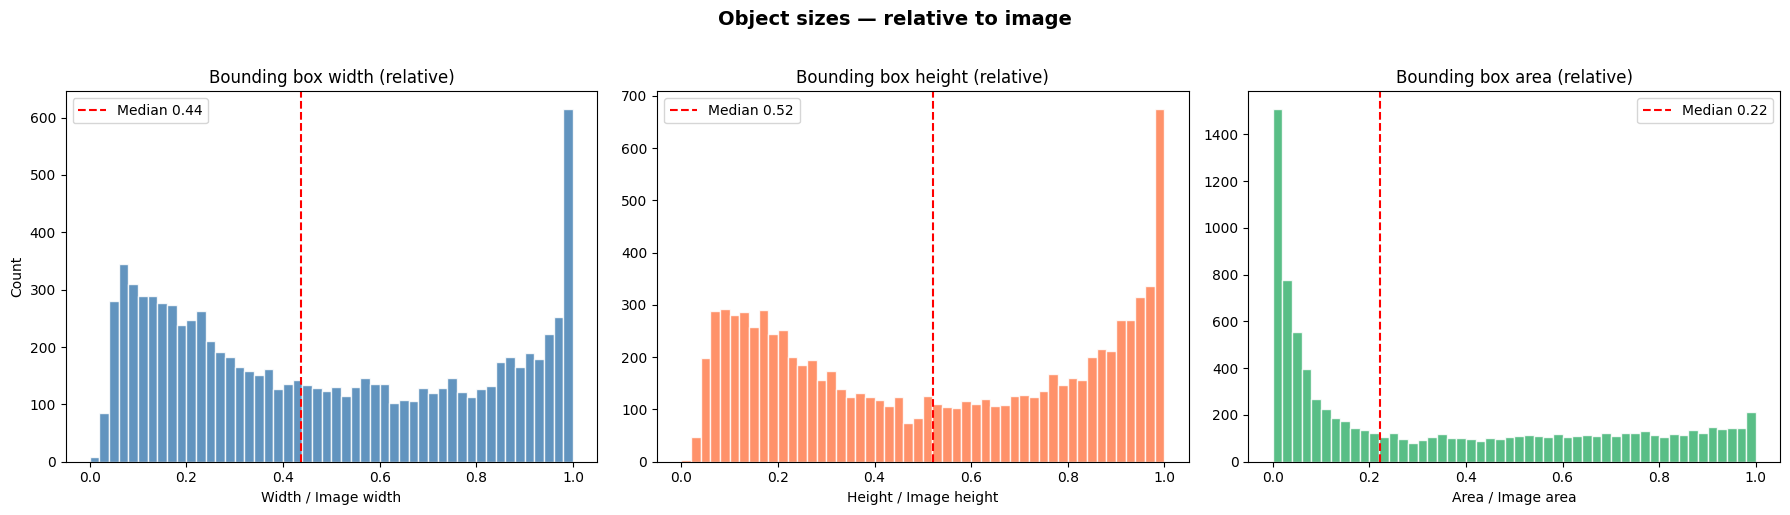

Metric                      Min     Median       Mean        Max
--------------------------------------------------------------
Width (px)                    0        185        246       1682
Height (px)                   0        174        240       1727
Area (px²)                    0      31316      93329    2288275
Rel. width                 0.00       0.44       0.49       1.00
Rel. height                0.00       0.52       0.53       1.00
Rel. area                  0.00       0.22       0.35       1.00


In [25]:
id_to_img = {img["id"]: img for img in merged["images"]}

box_w, box_h, box_area = [], [], []
rel_w, rel_h, rel_area = [], [], []

for a in merged["annotations"]:
    bx, by, bw, bh = [float(v) for v in a["bbox"]]
    img = id_to_img[a["image_id"]]
    iw, ih = float(img["width"]), float(img["height"])

    box_w.append(bw)
    box_h.append(bh)
    box_area.append(bw * bh)

    rel_w.append(bw / iw)
    rel_h.append(bh / ih)
    rel_area.append((bw * bh) / (iw * ih))

box_w = np.array(box_w)
box_h = np.array(box_h)
box_area = np.array(box_area)
rel_w = np.array(rel_w)
rel_h = np.array(rel_h)
rel_area = np.array(rel_area)

# --- Absolute sizes ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(box_w, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(np.median(box_w), color="red", linestyle="--", label=f"Median {np.median(box_w):.0f}px")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Count")
axes[0].set_title("Bounding box width (absolute)")
axes[0].legend()

axes[1].hist(box_h, bins=50, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(box_h), color="red", linestyle="--", label=f"Median {np.median(box_h):.0f}px")
axes[1].set_xlabel("Height (px)")
axes[1].set_title("Bounding box height (absolute)")
axes[1].legend()

axes[2].hist(box_area, bins=50, color="mediumseagreen", edgecolor="white", alpha=0.85)
axes[2].axvline(np.median(box_area), color="red", linestyle="--", label=f"Median {np.median(box_area):.0f}px²")
axes[2].set_xlabel("Area (px²)")
axes[2].set_title("Bounding box area (absolute)")
axes[2].legend()

plt.suptitle("Object sizes — absolute", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Relative sizes (fraction of image) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rel_w, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(np.median(rel_w), color="red", linestyle="--", label=f"Median {np.median(rel_w):.2f}")
axes[0].set_xlabel("Width / Image width")
axes[0].set_ylabel("Count")
axes[0].set_title("Bounding box width (relative)")
axes[0].legend()

axes[1].hist(rel_h, bins=50, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(rel_h), color="red", linestyle="--", label=f"Median {np.median(rel_h):.2f}")
axes[1].set_xlabel("Height / Image height")
axes[1].set_title("Bounding box height (relative)")
axes[1].legend()

axes[2].hist(rel_area, bins=50, color="mediumseagreen", edgecolor="white", alpha=0.85)
axes[2].axvline(np.median(rel_area), color="red", linestyle="--", label=f"Median {np.median(rel_area):.2f}")
axes[2].set_xlabel("Area / Image area")
axes[2].set_title("Bounding box area (relative)")
axes[2].legend()

plt.suptitle("Object sizes — relative to image", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print(f"{'Metric':<20} {'Min':>10} {'Median':>10} {'Mean':>10} {'Max':>10}")
print("-" * 62)
for name, arr in [("Width (px)", box_w), ("Height (px)", box_h), ("Area (px²)", box_area),
                  ("Rel. width", rel_w), ("Rel. height", rel_h), ("Rel. area", rel_area)]:
    fmt = ".2f" if "Rel" in name else ".0f"
    print(f"{name:<20} {np.min(arr):>10{fmt}} {np.median(arr):>10{fmt}} "
          f"{np.mean(arr):>10{fmt}} {np.max(arr):>10{fmt}}")

## Generate instance masks with SAM2

Use Ultralytics SAM2 with bounding box prompts to generate per-flower segmentation masks. These masks will be used for Copy-Paste synthetic data generation.

In [ ]:
from ultralytics import SAM

sam_model = SAM("sam2.1_b.pt")

with open("mixed_flowers/_annotations.coco.json") as f:
    merged = json.load(f)

mask_dir = os.path.join("mixed_flowers", "masks")
os.makedirs(mask_dir, exist_ok=True)

id_to_img = {img["id"]: img for img in merged["images"]}
img_anns = {}
for a in merged["annotations"]:
    img_anns.setdefault(a["image_id"], []).append(a)

total_masks = 0
failed = 0

for img_id in tqdm(sorted(img_anns.keys()), desc="Generating masks"):
    img_info = id_to_img[img_id]
    img_path = os.path.join("mixed_flowers", "images", img_info["file_name"])

    if not os.path.exists(img_path):
        failed += 1
        continue

    anns = img_anns[img_id]
    bboxes_xyxy = []
    for a in anns:
        x, y, w, h = [float(v) for v in a["bbox"]]
        bboxes_xyxy.append([x, y, x + w, y + h])

    try:
        results = sam_model(img_path, bboxes=bboxes_xyxy, verbose=False)

        if results and results[0].masks is not None:
            masks_np = results[0].masks.data.cpu().numpy()
            for i, a in enumerate(anns):
                if i < len(masks_np):
                    mask = (masks_np[i] * 255).astype(np.uint8)
                    mask_fname = f"mask_{a['id']:06d}.png"
                    cv2.imwrite(os.path.join(mask_dir, mask_fname), mask)
                    total_masks += 1
    except Exception as e:
        failed += 1
        if failed <= 5:
            print(f"  Error on {img_info['file_name']}: {e}")

print(f"\nDone! Generated {total_masks} masks in {mask_dir}/")
print(f"Failed/skipped: {failed} images")

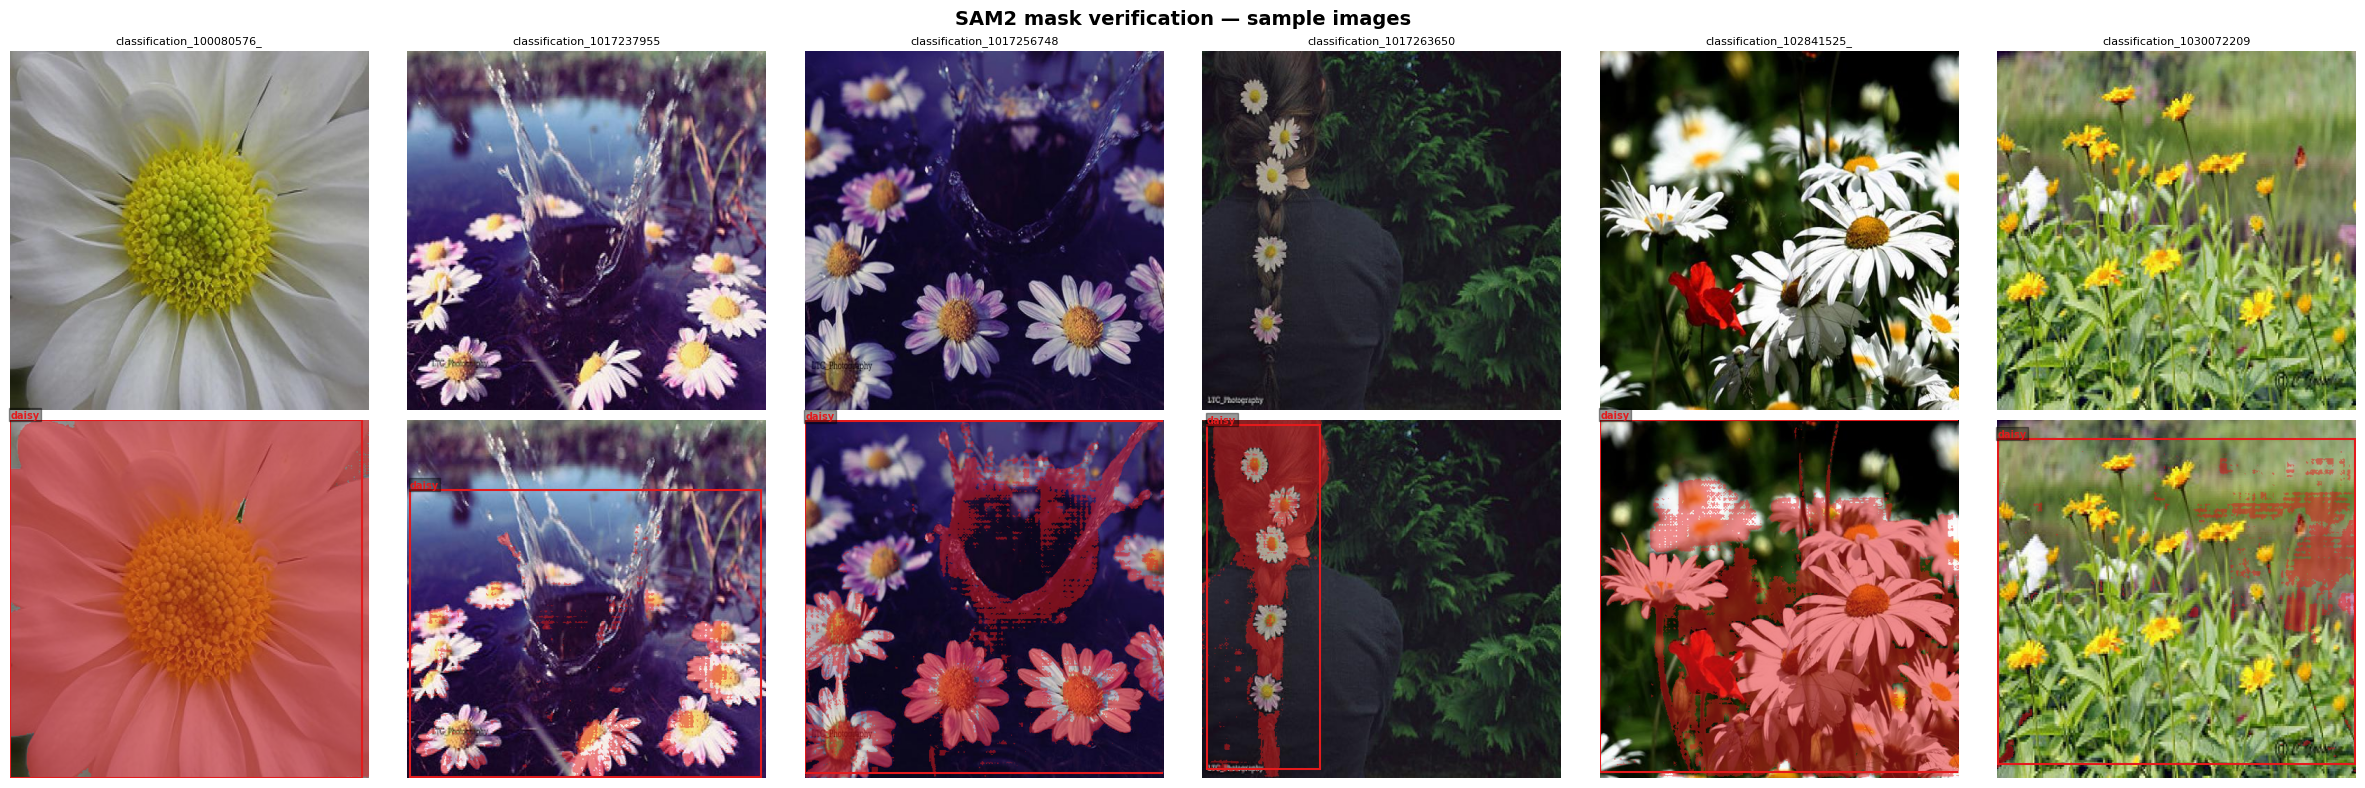

In [28]:
cat_map = {c["id"]: c["name"] for c in merged["categories"]}
sample_ids = list(img_anns.keys())[:6]

fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for col, img_id in enumerate(sample_ids):
    img_info = id_to_img[img_id]
    img_path = os.path.join("mixed_flowers", "images", img_info["file_name"])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    axes[0, col].imshow(img)
    axes[0, col].set_title(img_info["file_name"][:25], fontsize=8)
    axes[0, col].axis("off")

    overlay = img.copy()
    anns = img_anns[img_id]
    colors = plt.cm.Set1(np.linspace(0, 1, max(len(anns), 1)))

    for i, a in enumerate(anns):
        mask_path = os.path.join(mask_dir, f"mask_{a['id']:06d}.png")
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) > 127
            if mask.shape != img.shape[:2]:
                mask = cv2.resize(mask.astype(np.uint8), (img.shape[1], img.shape[0])) > 0
            color = (np.array(colors[i][:3]) * 255).astype(np.uint8)
            overlay[mask] = overlay[mask] * 0.5 + color * 0.5

        x, y, w, h = [float(v) for v in a["bbox"]]
        name = cat_map[a["category_id"]]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5,
                                  edgecolor=colors[i], facecolor="none")
        axes[1, col].add_patch(rect)
        axes[1, col].text(x, y - 3, name, color=colors[i], fontsize=7,
                          fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=1))

    axes[1, col].imshow(overlay)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Mask overlay + bbox", fontsize=12)
plt.suptitle("SAM2 mask verification — sample images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Copy-Paste synthetic data generation

Extract flower instances using SAM masks, then paste them onto generated backgrounds (solid colors, gradients, noise textures) with random placement, scale, and rotation to create new training images with automatic bounding box annotations.

In [35]:
import random

MERGED_DIR = "mixed_flowers"
SYNTH_DIR = os.path.join(MERGED_DIR, "synthetic")
SYNTH_IMG_DIR = os.path.join(SYNTH_DIR, "images")
os.makedirs(SYNTH_IMG_DIR, exist_ok=True)

with open(os.path.join(MERGED_DIR, "_annotations.coco.json")) as f:
    merged = json.load(f)

mask_dir = os.path.join(MERGED_DIR, "masks")
cat_map = {c["id"]: c["name"] for c in merged["categories"]}
id_to_img = {img["id"]: img for img in merged["images"]}

# Build list of usable flower instances (annotation + mask file exists)
instances = []
for a in merged["annotations"]:
    mask_path = os.path.join(mask_dir, f"mask_{a['id']:06d}.png")
    if os.path.exists(mask_path):
        instances.append(a)

print(f"Usable flower instances with masks: {len(instances)}")
print(f"Categories: {len(cat_map)}")

# --- Background generators ---

def bg_solid(h, w):
    color = np.random.randint(30, 230, size=3, dtype=np.uint8)
    return np.full((h, w, 3), color, dtype=np.uint8)

def bg_gradient(h, w):
    c1 = np.random.randint(20, 220, size=3).astype(np.float32)
    c2 = np.random.randint(20, 220, size=3).astype(np.float32)
    if random.random() < 0.5:
        t = np.linspace(0, 1, w).reshape(1, -1, 1)
    else:
        t = np.linspace(0, 1, h).reshape(-1, 1, 1)
    bg = ((1 - t) * c1 + t * c2).astype(np.uint8)
    return np.broadcast_to(bg, (h, w, 3)).copy()

def bg_noise(h, w):
    noise = np.random.randint(0, 255, (h, w, 3), dtype=np.uint8)
    return cv2.GaussianBlur(noise, (0, 0), sigmaX=random.uniform(8, 25))

bg_generators = [bg_solid, bg_gradient, bg_noise]

# --- Flower extraction & pasting ---

def extract_flower(ann):
    """Extract RGBA flower cutout using its mask."""
    img_info = id_to_img[ann["image_id"]]
    img_path = os.path.join(MERGED_DIR, "images", img_info["file_name"])
    img = cv2.imread(img_path)

    mask_path = os.path.join(mask_dir, f"mask_{ann['id']:06d}.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        return None

    if mask.shape[:2] != img.shape[:2]:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    x, y, w, h = [int(float(v)) for v in ann["bbox"]]
    pad = 5
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(img.shape[1], x + w + pad)
    y2 = min(img.shape[0], y + h + pad)

    crop = img[y1:y2, x1:x2]
    mask_crop = mask[y1:y2, x1:x2]

    alpha = (mask_crop > 127).astype(np.uint8) * 255
    rgba = np.dstack([crop, alpha])
    return rgba

def paste_flower(canvas, rgba, scale, angle):
    """Paste an RGBA flower onto canvas with scale and rotation. Returns bbox or None."""
    fh, fw = rgba.shape[:2]
    new_w, new_h = int(fw * scale), int(fh * scale)
    if new_w < 10 or new_h < 10:
        return None

    rgba_resized = cv2.resize(rgba, (new_w, new_h), interpolation=cv2.INTER_AREA)

    center = (new_w // 2, new_h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    rot_w = int(new_h * sin + new_w * cos)
    rot_h = int(new_h * cos + new_w * sin)
    M[0, 2] += rot_w / 2 - center[0]
    M[1, 2] += rot_h / 2 - center[1]

    rgba_rot = cv2.warpAffine(rgba_resized, M, (rot_w, rot_h), borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0, 0))

    ch, cw = canvas.shape[:2]
    max_x = cw - rot_w
    max_y = ch - rot_h
    if max_x < 0 or max_y < 0:
        return None

    px = random.randint(0, max_x)
    py = random.randint(0, max_y)

    alpha = rgba_rot[:, :, 3:4].astype(np.float32) / 255.0
    rgb = rgba_rot[:, :, :3]

    roi = canvas[py:py + rot_h, px:px + rot_w]
    canvas[py:py + rot_h, px:px + rot_w] = (rgb * alpha + roi * (1 - alpha)).astype(np.uint8)

    # Compute tight bbox from alpha
    mask_binary = rgba_rot[:, :, 3] > 127
    ys, xs = np.where(mask_binary)
    if len(xs) == 0:
        return None
    bx = int(px + xs.min())
    by = int(py + ys.min())
    bw = int(xs.max() - xs.min())
    bh = int(ys.max() - ys.min())
    return [bx, by, bw, bh]

# --- Generate synthetic images ---

NUM_SYNTH = 500
CANVAS_SIZE = (640, 640)
FLOWERS_PER_IMAGE = (1, 5)
SCALE_RANGE = (0.4, 1.6)
ANGLE_RANGE = (-30, 30)

synth_coco = {
    "info": {"description": "Synthetic Copy-Paste flower dataset", "version": "1.0",
             "date_created": datetime.now().isoformat()},
    "licenses": [{"id": 1, "name": "Synthetic"}],
    "categories": merged["categories"],
    "images": [],
    "annotations": [],
}

synth_img_id = 0
synth_ann_id = 0

for i in tqdm(range(NUM_SYNTH), desc="Generating synthetic images"):
    h, w = CANVAS_SIZE
    bg_fn = random.choice(bg_generators)
    canvas = bg_fn(h, w)

    n_flowers = random.randint(*FLOWERS_PER_IMAGE)
    sampled = random.choices(instances, k=n_flowers)

    placed = False
    for ann in sampled:
        rgba = extract_flower(ann)
        if rgba is None:
            continue

        scale = random.uniform(*SCALE_RANGE)
        angle = random.uniform(*ANGLE_RANGE)
        bbox = paste_flower(canvas, rgba, scale, angle)

        if bbox is not None:
            synth_coco["annotations"].append({
                "id": synth_ann_id,
                "image_id": synth_img_id,
                "category_id": ann["category_id"],
                "bbox": bbox,
                "area": bbox[2] * bbox[3],
                "iscrowd": 0,
                "segmentation": [],
            })
            synth_ann_id += 1
            placed = True

    if placed:
        fname = f"synth_{synth_img_id:05d}.jpg"
        cv2.imwrite(os.path.join(SYNTH_IMG_DIR, fname), canvas)
        synth_coco["images"].append({
            "id": synth_img_id,
            "file_name": fname,
            "height": h,
            "width": w,
        })
        synth_img_id += 1

out_path = os.path.join(SYNTH_DIR, "_annotations.coco.json")
with open(out_path, "w") as f:
    json.dump(synth_coco, f)

print(f"\nSaved to {out_path}")
print(f"Synthetic images: {len(synth_coco['images'])}")
print(f"Annotations:      {len(synth_coco['annotations'])} boxes")
print(f"Categories:       {len(synth_coco['categories'])}")

Usable flower instances with masks: 8924
Categories: 16


Generating synthetic images: 100%|██████████| 500/500 [01:19<00:00,  6.26it/s]



Saved to mixed_flowers\synthetic\_annotations.coco.json
Synthetic images: 482
Annotations:      1217 boxes
Categories:       16


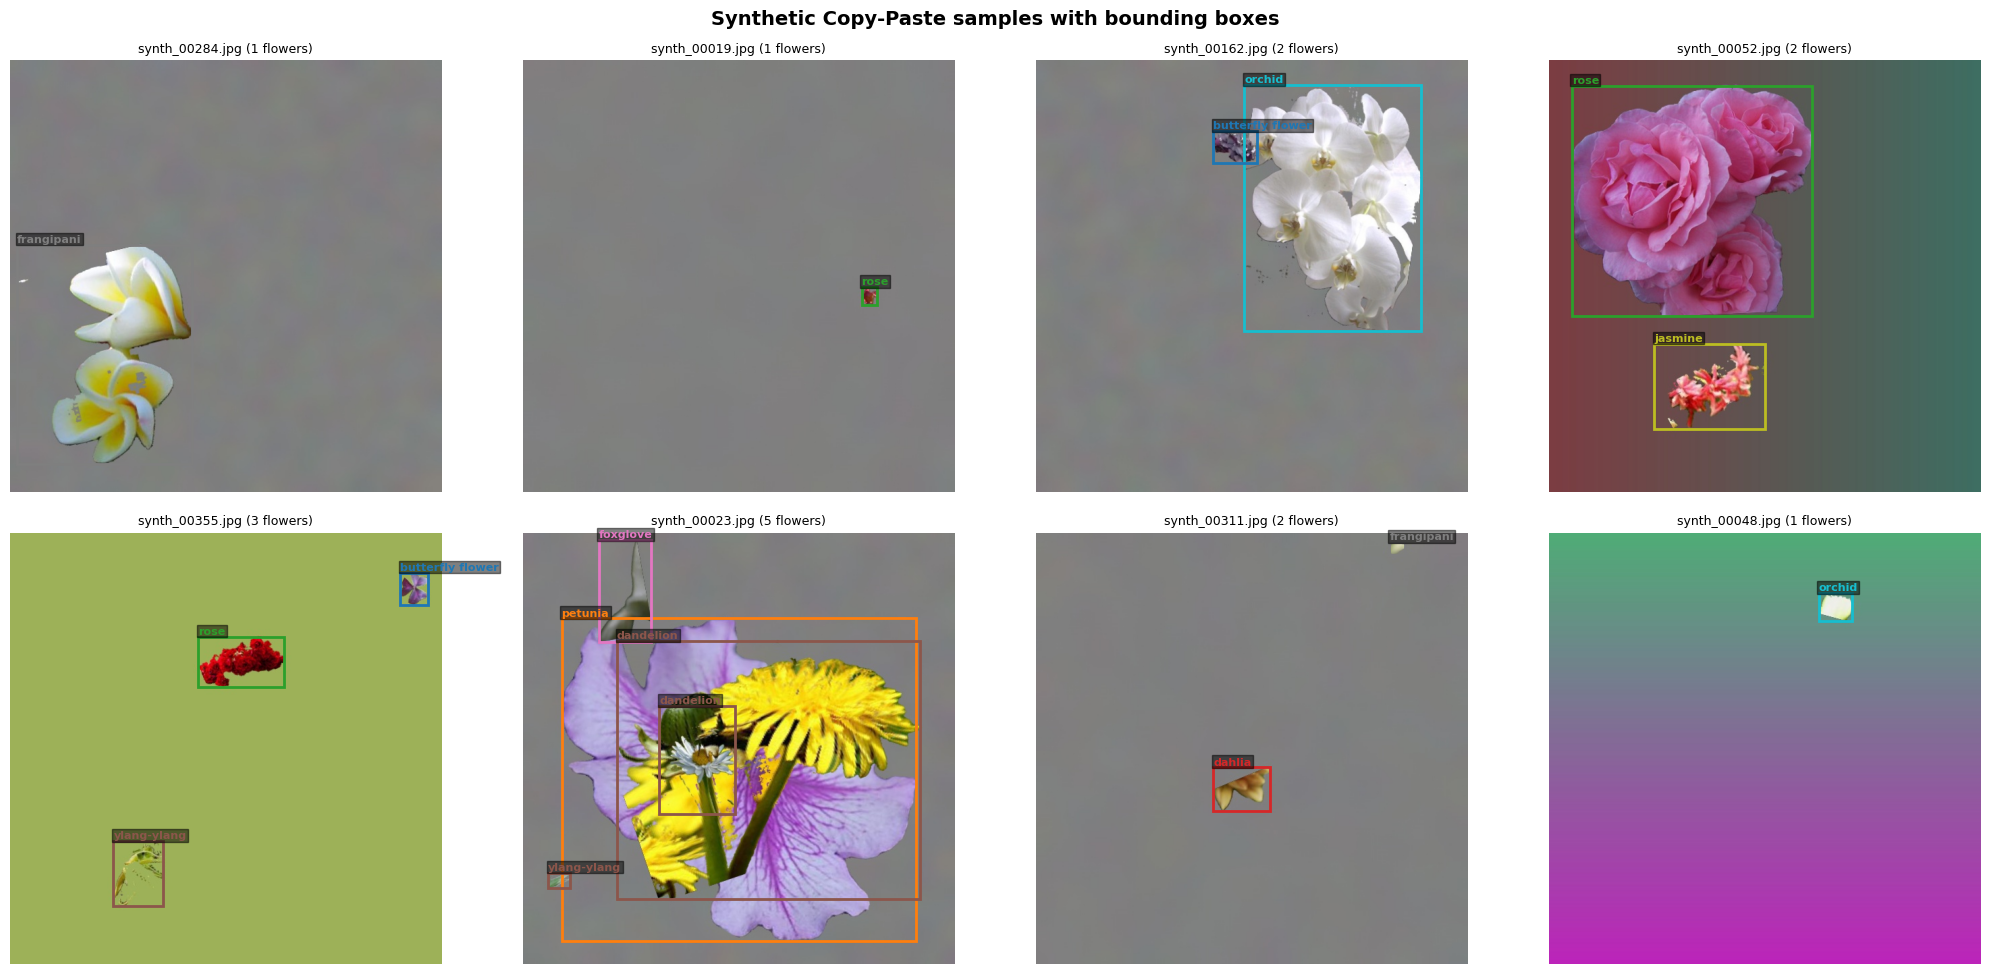

In [38]:
synth_cat_map = {c["id"]: c["name"] for c in synth_coco["categories"]}
synth_img_anns = {}
for a in synth_coco["annotations"]:
    synth_img_anns.setdefault(a["image_id"], []).append(a)

sample_ids = random.sample(list(synth_img_anns.keys()), min(8, len(synth_img_anns)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
colors = plt.cm.tab10.colors

for idx, img_id in enumerate(sample_ids):
    ax = axes[idx // 4, idx % 4]
    img_info = synth_coco["images"][img_id]
    img = cv2.cvtColor(cv2.imread(os.path.join(SYNTH_IMG_DIR, img_info["file_name"])),
                        cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    for a in synth_img_anns[img_id]:
        x, y, w, h = a["bbox"]
        name = synth_cat_map[a["category_id"]]
        c = colors[a["category_id"] % len(colors)]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=c, facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 4, name, color=c, fontsize=8, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.5, pad=1))

    n = len(synth_img_anns[img_id])
    ax.set_title(f"{img_info['file_name']} ({n} flowers)", fontsize=9)
    ax.axis("off")

plt.suptitle("Synthetic Copy-Paste samples with bounding boxes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()